In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

""" gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e) """

# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

In [2]:
print('tensorflow version: ',tf.__version__)
print('available gpus: ', tf.config.list_physical_devices('GPU')) # gpus?

tensorflow version:  2.10.0
available gpus:  []


In [3]:
'''
Data preparation:
'''

data = pd.read_csv('XFEL_KW0_Results_2.csv', names=None)

# find constant columns, else normalization wouldn't work
data = data.loc[:, (data != data.iloc[0]).any()] 

# label input 0-6, output 0-4 just for clarity
num_inputs = 7
num_outputs = 5
data.columns = np.concatenate(
    (["Input %s" % i for i in range(num_inputs)], ["Output %s" % i for i in range(num_outputs)])
)

In [13]:
# normalization to: mean=0, std=1
normalized_data = (data-data.mean())/data.std()

# TODO: k-fold cross-validation
train, test = train_test_split(normalized_data, test_size=0.2, random_state=42, shuffle=True)
#train, validation = train_test_split(train, test_size=0.2, random_state=42, shuffle=True)

# numpy indexing [columns_start : columns_end, rows_start : rows_end]
x_train, y_train = train.iloc[:,:num_inputs], train.iloc[:,num_inputs:]
#x_val, y_val = validation.iloc[:,:num_inputs], validation.iloc[:,num_inputs:]
x_test, y_test = test.iloc[:,:num_inputs], test.iloc[:,num_inputs:]
x_train

print('data preparation done')

data preparation done


In [11]:
#with tf.device('/device:GPU:0'):
model = tf.keras.Sequential([
    tf.keras.Input(shape=7),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(5),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['accuracy'],
)

history = model.fit(
    x_train, y_train,
    batch_size=200,
    epochs=500,
    validation_data = (x_test, y_test),
)

Epoch 1/500
3619/3619 [==============================] - 8s 2ms/step - loss: 0.0410 - accuracy: 0.9299 - val_loss: 0.0203 - val_accuracy: 0.9457
Epoch 2/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0158 - accuracy: 0.9492 - val_loss: 0.0120 - val_accuracy: 0.9505
Epoch 3/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0138 - accuracy: 0.9520 - val_loss: 0.0149 - val_accuracy: 0.9513
Epoch 4/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0126 - accuracy: 0.9536 - val_loss: 0.0163 - val_accuracy: 0.9514
Epoch 5/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0123 - accuracy: 0.9551 - val_loss: 0.0126 - val_accuracy: 0.9569
Epoch 6/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0117 - accuracy: 0.9573 - val_loss: 0.0179 - val_accuracy: 0.9546
Epoch 7/500
3619/3619 [==============================] - 7s 2ms/step - loss: 0.0109 - accuracy: 0.9596 - val_loss: 0.0090 - val_ac

In [16]:
""" # Model creation
def create_model(hidden_depth = 1, lr=0.01, actv_fct='relu'):
    model = keras.Sequential([
        keras.Input(shape=(num_inputs)),
        *[
            keras.layers.Dense(16, activation=actv_fct) 
            for _ in range(hidden_depth)
        ],
        keras.layers.Dense(num_outputs)
    ])
    
    print(model.summary())
    print('hidden depth:', hidden_depth, 'learning rate: ', lr, ' activation function: ', actv_fct)

    optimizer = keras.optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

print('defined model creation method') """

In [17]:
""" # Gridsearch with k-fold cross validation

param_grid = {
    'hidden_depth': [i for i in range(1,6)],
    'lr': [0.005*i for i in range(1,4)],
    'actv_fct': ['relu', 'sigmoid']
}
loss = keras.losses.MeanSquaredError()

model = KerasRegressor(build_fn=create_model)

# Specify the number of folds for cross-validation
n_splits = 3

# Create a cross-validation object (KFold in this case)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform grid search with cross-validation
print('starting grid-search')
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, scoring='neg_mean_squared_error')
grid_result = grid.fit(x_train, y_train)

# Print the best hyperparameters and results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_)) """

C:\Users\maris\AppData\Local\Temp\ipykernel_4724\2776945825.py:13: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasRegressor(build_fn=create_model)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                128       
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 5)                 85        
                                                                 
Total params: 485
Trainable params: 485
Non-trainable params: 0
_________________________________________________________________
None
hidden depth: 2 learning rate:  0.01  activation function:  relu
9424/9424 [==============================] - 7s 711us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 16)

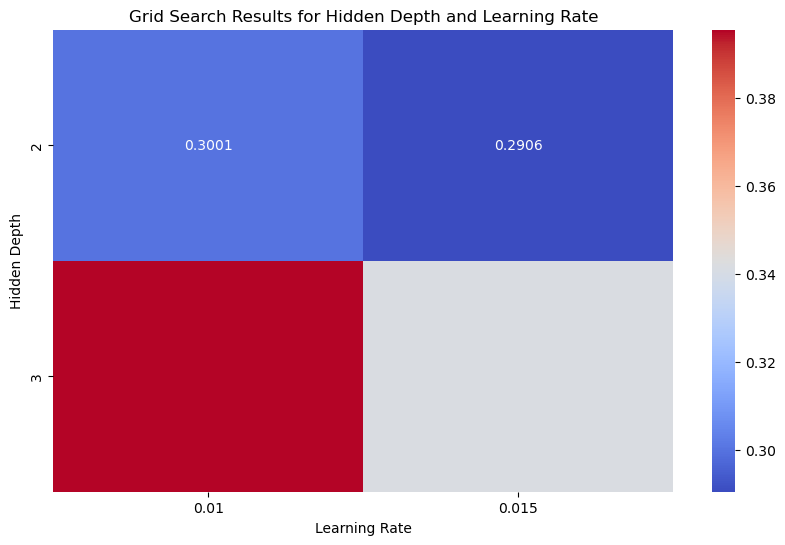

In [20]:
""" # Extract the results from the grid search
results = grid_result.cv_results_
hidden_depths = results['param_hidden_depth']
learning_rates = results['param_lr']
mean_test_scores = -results['mean_test_score']  # Negate for MSE

# Create a pivot table for the heatmap
pivot_table = pd.pivot_table(pd.DataFrame({'Hidden Depth': hidden_depths, 'Learning Rate': learning_rates, 'Mean Test Score': mean_test_scores}),
                            values='Mean Test Score', index='Hidden Depth', columns='Learning Rate')

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='coolwarm', cbar=True)
plt.title('Grid Search Results for Hidden Depth and Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Hidden Depth')

plt.savefig('results_oder_sowas.png') """

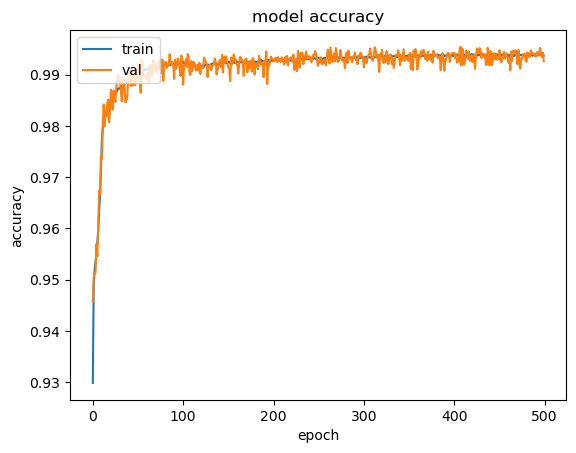

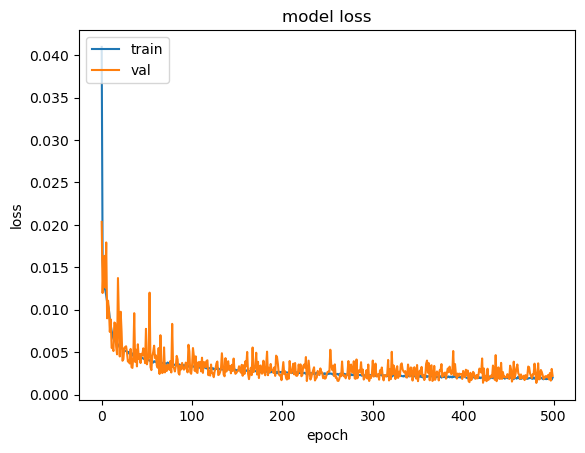

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [17]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=7),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(5),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['accuracy'],
)

history2 = model.fit(
    x_train, y_train,
    batch_size=200,
    epochs=2000,
    validation_data = (x_test, y_test),
)

Epoch 1/2000
4524/4524 [==============================] - 9s 2ms/step - loss: 0.0356 - accuracy: 0.9328 - val_loss: 0.0143 - val_accuracy: 0.9523
Epoch 2/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0144 - accuracy: 0.9511 - val_loss: 0.0150 - val_accuracy: 0.9502
Epoch 3/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0127 - accuracy: 0.9537 - val_loss: 0.0127 - val_accuracy: 0.9527
Epoch 4/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0114 - accuracy: 0.9574 - val_loss: 0.0082 - val_accuracy: 0.9634
Epoch 5/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0090 - accuracy: 0.9724 - val_loss: 0.0073 - val_accuracy: 0.9752
Epoch 6/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0077 - accuracy: 0.9800 - val_loss: 0.0058 - val_accuracy: 0.9816
Epoch 7/2000
4524/4524 [==============================] - 8s 2ms/step - loss: 0.0073 - accuracy: 0.9811 - val_loss: 0.0057 -

In [84]:
""" # Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(xtest, ytest, batch_size=128)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(xtest[:3])
print("example predictions:\n", predictions) """

Evaluate on test data
1767/1767 [==============================] - 4s 2ms/step - loss: 2.0094e-04 - accuracy: 0.9647
test loss, test acc: [0.00020094368665013462, 0.9647071957588196]
Generate predictions for 3 samples
1/1 [==============================] - 0s 129ms/step
example predictions:
 [[0.469 0.407 0.176 0.463]
 [0.603 0.601 0.203 0.779]
 [0.66  0.415 0.162 0.564]]
